In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/IMDB Dataset.csv")

In [5]:
 df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
df.shape

(50000, 2)

In [9]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df = df.drop_duplicates()

In [12]:
df.isnull().sum()

,0
review,0
sentiment,0


In [13]:
df['review'] = df['review'].str.lower()

/tmp/ipykernel_41898/724319867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].str.lower()


In [14]:
import re
def remove_html_tags(text):
    if not isinstance(text, str):
        return text
    pattern = re.compile(r'<.*?>')
    return pattern.sub('', text)


df['review'] = df['review'].apply(remove_html_tags)

/tmp/ipykernel_41898/4084926938.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_html_tags)


In [15]:
def remove_url(text):
     if not isinstance(text, str):
        return text
     pattern = re.compile(r'https?://\S+|www\.\S+')
     return pattern.sub(r'', text)
df['review'] = df['review'].apply(remove_url)

/tmp/ipykernel_41898/1347684568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_url)


In [16]:
import string,time
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [17]:
exclude = string.punctuation

In [18]:
def remove_punc1(text):
    if not isinstance(text, str):
        return text
    for char in exclude:
        text = text.replace(char,'')
    return text


In [19]:
df['review'] = df['review'].apply(remove_punc1)

/tmp/ipykernel_41898/3849302935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_punc1)


In [20]:
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [21]:
def chat_conversion(text):
    if not isinstance(text, str):
        return text
    new_text = []
    for w in text.split():
        if w.upper() in chat_words:
            new_text.append(chat_words[w.upper()])
        else:
            new_text.append(w)
    return " ".join(new_text)
df['review'] = df['review'].apply(chat_conversion)

/tmp/ipykernel_41898/2188565738.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(chat_conversion)


In [22]:
from textblob import TextBlob

In [23]:
df['review'] = df['review'].apply(lambda x: str(TextBlob(x)))

/tmp/ipykernel_41898/3898957683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(lambda x: str(TextBlob(x)))


In [24]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 3.7 MB/s eta 0:00:00


In [25]:
import emoji
def em(text):
  return emoji.demojize(text)

In [26]:
df['review'] = df['review'].apply(em)

/tmp/ipykernel_41898/2840356209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(em)


In [27]:
pip install nltk

In [28]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [29]:
stopword = stopwords.words('english')

In [30]:
def remove_stopwords(text):
    new_text = []
    sw = set(stopwords.words('english'))
    negations_to_keep = {
        "not", "no", "nor", "never", "none",
        "n't", "don't", "doesn't", "didn't", "won't", "wouldn't",
        "shouldn't", "couldn't", "can't", "cannot", "ain't"
    }

    for word in text.split():
        w = word.lower()
        if w in negations_to_keep or w.endswith(("n't", "not")):
            new_text.append(word)
        elif w in sw:
            continue

        else:
            new_text.append(word)

    return " ".join(new_text)

In [31]:
df['review'] = df['review'].apply(remove_stopwords)

/tmp/ipykernel_41898/3992406652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_stopwords)


In [32]:
def remove_spaces(text):
    return " ".join(text.split())

In [33]:
df['review'] = df['review'].apply(remove_spaces)

/tmp/ipykernel_41898/3747246006.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_spaces)


In [34]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [35]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

df['review'] = df['review'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_41898/3813466615.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(word_tokenize)


In [36]:
df

,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, Tears, eyes, ...",positive
3,"[basically, theres, family, little, boy, jake,...",negative
4,"[petter, matteis, love, Tears, eyes, money, vi...",positive
...,...,...
49995,"[thought, movie, right, good, job, wasnt, crea...",positive
49996,"[bad, plot, bad, dialogue, bad, acting, idioti...",negative
49997,"[catholic, taught, parochial, elementary, scho...",negative
49998,"[im, going, disagree, previous, comment, side,...",negative


In [37]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def stemming(words):
    return [ps.stem(word) for word in words]

df['review'] = df['review'].apply(stemming)

/tmp/ipykernel_41898/443994333.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(stemming)


In [38]:
df['review'] = df['review'].apply(lambda x: " ".join(x))

/tmp/ipykernel_41898/1850297493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(lambda x: " ".join(x))


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)

X = cv.fit_transform(df['review']).toarray()

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['sentiment'])

In [41]:
df

,review,sentiment
0,one review mention watch 1 oz episod youll hoo...,positive
1,wonder littl product film techniqu unassum old...,positive
2,thought wonder way spend tear eye hot summer w...,positive
3,basic there famili littl boy jake think there ...,negative
4,petter mattei love tear eye money visual stun ...,positive
...,...,...
49995,thought movi right good job wasnt creativ orig...,positive
49996,bad plot bad dialogu bad act idiot direct anno...,negative
49997,cathol taught parochi elementari school nun ta...,negative
49998,im go disagre previou comment side maltin one ...,negative


In [42]:
from sklearn.model_selection import train_test_split
X = df['review']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [44]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=4,
    max_iter=2000,
    solver='liblinear')

In [46]:
lr.fit(X_train_tfidf, y_train)

LogisticRegression(C=4, max_iter=2000, solver='liblinear')

In [47]:
y_pred_lr = lr.predict(X_test_tfidf)

In [48]:
lr_acc = accuracy_score(y_test, y_pred_lr)

In [49]:
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8950287385297974


In [50]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4939
           1       0.89      0.90      0.90      4978

    accuracy                           0.90      9917
   macro avg       0.90      0.89      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [51]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:\n")
print(cm_lr)


Confusion Matrix:

[[4371  568]
 [ 473 4505]]


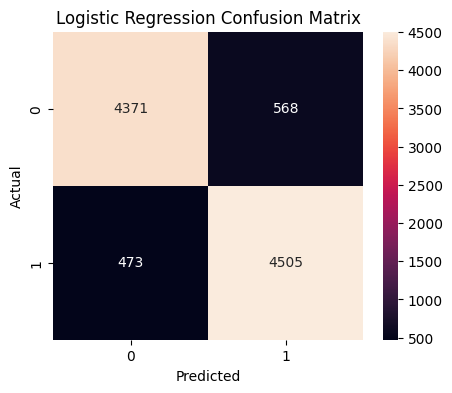

In [52]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_lr,
            annot=True,
            fmt='d')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB(alpha=0.3)

In [54]:
nb.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.3)

In [55]:
y_pred_nb = nb.predict(X_test_tfidf)

In [56]:
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8650801653725925


In [57]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      4939
           1       0.85      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [58]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("\nConfusion Matrix:\n")
print(cm_nb)


Confusion Matrix:

[[4185  754]
 [ 584 4394]]


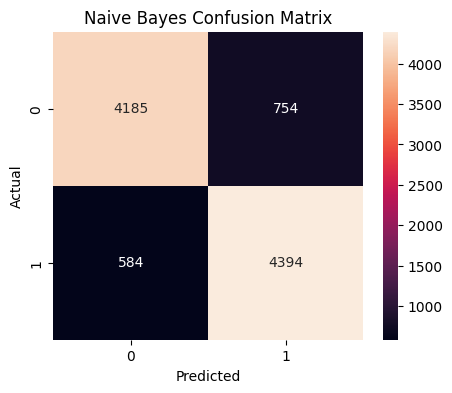

In [59]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_nb,
            annot=True,
            fmt='d')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini',
    max_depth=100,
    min_samples_split=20,min_samples_leaf=10, random_state=42)

In [61]:
dt.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(max_depth=100, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [62]:
y_pred_dt = dt.predict(X_test_tfidf)

In [63]:
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7266310376121811


In [64]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.74      0.73      4939
           1       0.73      0.72      0.73      4978

    accuracy                           0.73      9917
   macro avg       0.73      0.73      0.73      9917
weighted avg       0.73      0.73      0.73      9917



In [65]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n")
print(cm_dt)


Confusion Matrix:

[[3632 1307]
 [1404 3574]]


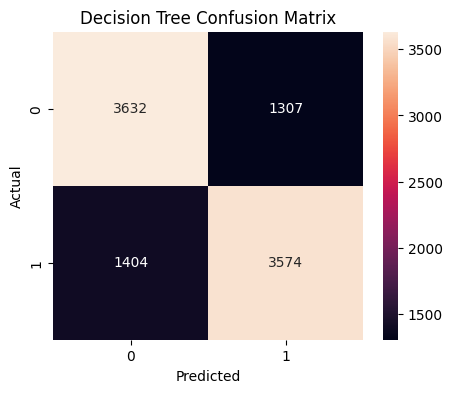

In [66]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_dt,
            annot=True,
            fmt='d')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [67]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,
    max_depth=50,
    min_samples_split=5,random_state=42,n_jobs=-1)

In [68]:
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(max_depth=50, min_samples_split=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [69]:
y_pred_rf = rf.predict(X_test_tfidf)

In [70]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.845114449934456


In [71]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      4939
           1       0.83      0.87      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n")
print(cm_rf)


Confusion Matrix:

[[4058  881]
 [ 655 4323]]


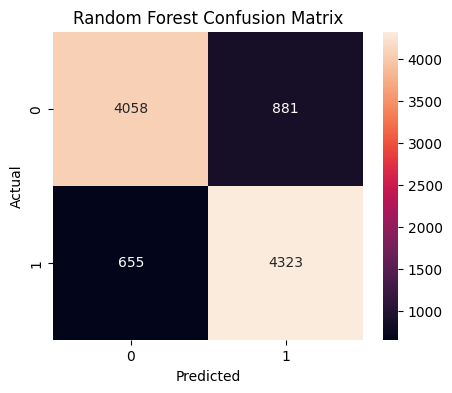

In [73]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [74]:
from sklearn.svm import LinearSVC
svm = LinearSVC(C=1.5,max_iter=5000)

In [75]:
svm.fit(X_train_tfidf, y_train)

LinearSVC(C=1.5, max_iter=5000)

In [76]:
y_pred_svm = svm.predict(X_test_tfidf)

In [77]:
svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8836341635575274


In [78]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4939
           1       0.88      0.89      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [79]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:\n")
print(cm_svm)


Confusion Matrix:

[[4326  613]
 [ 541 4437]]


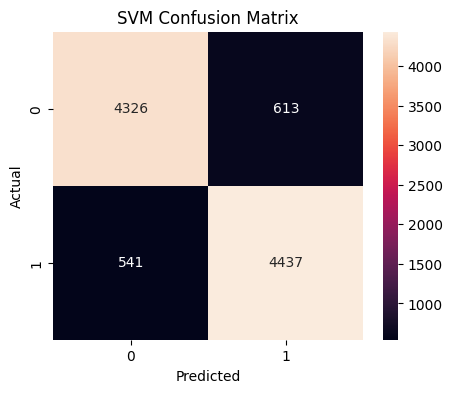

In [80]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_svm,
            annot=True,
            fmt='d')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [81]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb.predict(X_test_tfidf)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8466270041343148


In [82]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4939
           1       0.83      0.87      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [83]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:\n")
print(cm_xgb)


Confusion Matrix:

[[4041  898]
 [ 623 4355]]


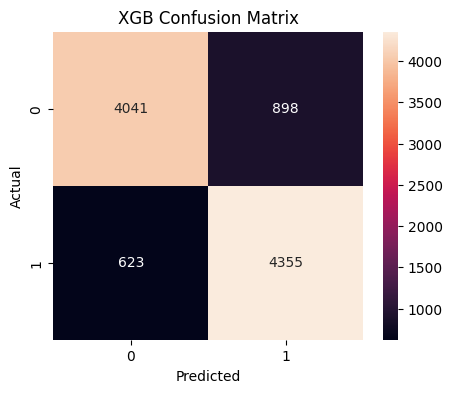

In [84]:
plt.figure(figsize=(5,4))

sns.heatmap(cm_xgb,
            annot=True,
            fmt='d')

plt.title("XGB Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

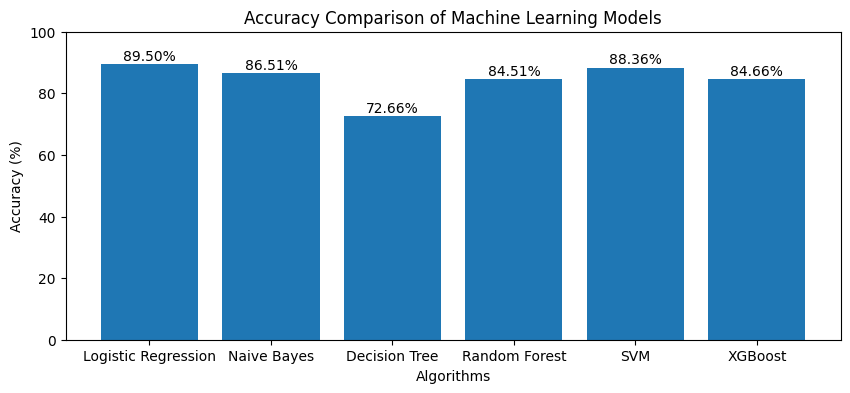

In [87]:
models = [
    'Logistic Regression',
    'Naive Bayes',
    'Decision Tree',
    'Random Forest',
    'SVM',
    'XGBoost',
]

accuracies = [
    lr_acc * 100,
    nb_acc * 100,
    dt_acc * 100,
    rf_acc * 100,
    svm_acc * 100,
    xgb_acc *100
]

plt.figure(figsize=(10,4))

bars = plt.bar(models, accuracies)

# Labels and title
plt.xlabel("Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Machine Learning Models")

# Show percentage above bars
for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.3,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0, 100)

plt.show()